---
title: earthkit-meteo: wind
short_title: Wind
---

## Earthkit-meteo: wind computations

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/jupyter-notebook-template/main?labpath=jupyter-notebook-template-copernicus.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/jupyter-notebook-template/blob/main/jupyter-notebook-template-copernicus.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/jupyter-notebook-template/blob/main/jupyter-notebook-template-copernicus.ipynb)

In [1]:
import earthkit.data as ekd
from earthkit.meteo import wind
import earthkit.plots as ekp

### Xarray

In [2]:
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B ...
    expver          (valid_time) <U4 64B dask.array<chunksize=(4,), meta=np.ndarray>
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB dask.array<chunksize=(4, 3, 301, 601), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
sp = wind.speed(ds.u,ds.v)
sp

<xarray.DataArray 'u' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 17MB
dask.array<transpose, shape=(4, 3, 301, 601), dtype=float64, chunksize=(4, 3, 301, 601), chunktype=numpy.ndarray>
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
    number          int64 8B ...
    expver          (valid_time) <U4 64B dask.array<chunksize=(4,), meta=np.ndarray>
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

In [6]:
# set metadata
sp.attrs["standard_name"] = "wind_speed"
sp.attrs["long_name"] = "wind_speed"
sp = sp.rename("ws")

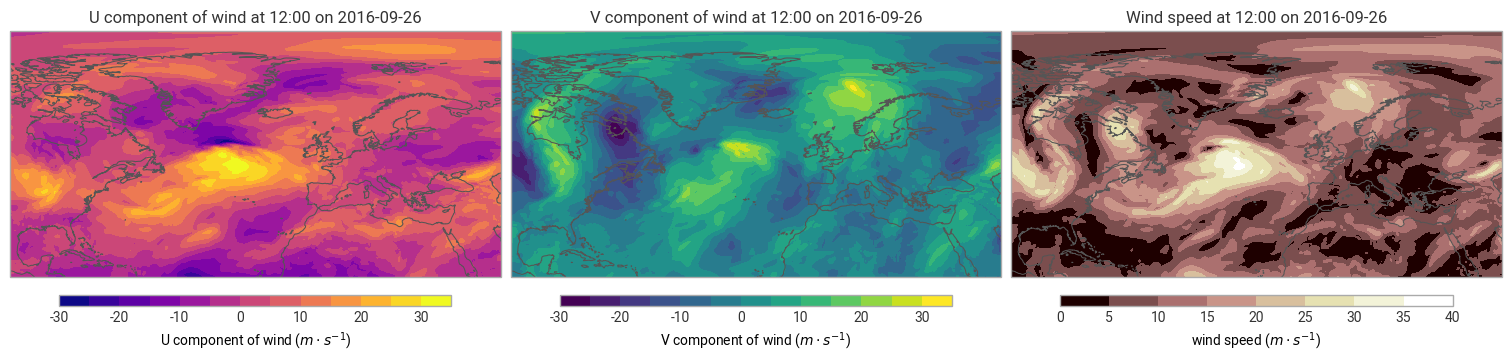

In [7]:
# select one level and step and plot input and resulting fields
u = ds.u.sel(pressure_level=700, valid_time="2016-09-26T12")
v = ds.v.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1 = sp.sel(pressure_level=700, valid_time="2016-09-26T12")
ekp.geo.plot(u, v, sp1)